1. THỐNG KÊ SỐ LƯỢNG VÀ ĐỌC DỮ LIỆU
Tổng số lượng sample trong cả 3 split: 5783
 - Số lượng tập TRAIN: 3068 samples
 - Số lượng tập DEV: 500 samples
 - Số lượng tập TEST: 2215 samples

2. THỐNG KÊ CLASS & TỈ LỆ (%)

Tập TRAIN:
 - Supported: 849 samples (27.67%)
 - Refuted: 1742 samples (56.78%)
 - Conflicting Evidence/Cherrypicking: 195 samples (6.36%)
 - Not Enough Evidence: 282 samples (9.19%)

Tập DEV:
 - Refuted: 305 samples (61.00%)
 - Supported: 122 samples (24.40%)
 - Not Enough Evidence: 35 samples (7.00%)
 - Conflicting Evidence/Cherrypicking: 38 samples (7.60%)

Tập TEST:
 - Unknown: 2215 samples (100.00%)

3. VẼ BIỂU ĐỒ CỘT (SỐ LƯỢNG THEO SPLIT)


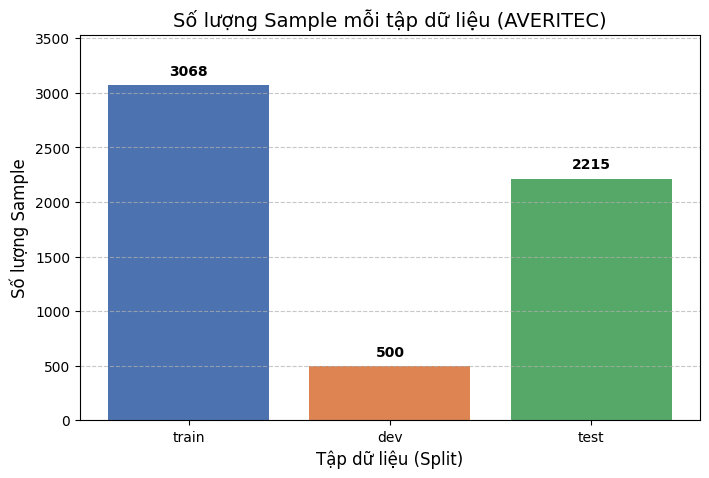


4. KHẢO SÁT CẤU TRÚC JSON (SCHEMA) ĐỆ QUY
Cấu trúc của 1 sample trong dataset:

- 'claim': str
- 'required_reannotation': bool
- 'label': str
- 'justification': str
- 'claim_date': str
- 'speaker': str
- 'original_claim_url': NoneType
- 'fact_checking_article': str
- 'reporting_source': str
- 'location_ISO_code': str
- 'claim_types': list
    [List contains elements of type: str]
- 'fact_checking_strategies': list
    [List contains elements of type: str]
- 'questions': list
    [List contains elements of type: dict]
        - 'question': str
        - 'answers': list
            [List contains elements of type: dict]
                - 'answer': str
                - 'answer_type': str
                - 'source_url': str
                - 'source_medium': str
                - 'boolean_explanation': str
                - 'cached_source_url': str
- 'cached_original_claim_url': NoneType


In [3]:
import os
import json
import matplotlib.pyplot as plt
from collections import Counter

# Đã cập nhật đúng đường dẫn tuyệt đối trên máy của bạn
DATA_STORE_PATH = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/'
SPLIT = ['train', 'dev', 'test']

total_samples = 0
split_counts = {}
class_stats_per_split = {}
sample_for_schema = None 

print("="*50)
print("1. THỐNG KÊ SỐ LƯỢNG VÀ ĐỌC DỮ LIỆU")
print("="*50)

for sp in SPLIT:
    # SỬA LỖI TẠI ĐÂY: Trỏ trực tiếp vào file .json thay vì coi nó là thư mục
    file_path = os.path.join(DATA_STORE_PATH, f"{sp}.json")
    
    split_data = []
    
    # Kiểm tra xem file có tồn tại không trước khi đọc
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                if isinstance(data, list):
                    split_data.extend(data)
                elif isinstance(data, dict):
                    split_data.append(data)
            except json.JSONDecodeError:
                f.seek(0)
                for line in f:
                    if line.strip():
                        split_data.append(json.loads(line))
        
        # Cập nhật số lượng
        count = len(split_data)
        split_counts[sp] = count
        total_samples += count
        
        # Lấy nhãn dựa trên sample bạn cung cấp (dùng key 'label')
        classes = [item.get('label', 'Unknown') for item in split_data]
        class_counts = dict(Counter(classes))
        class_stats_per_split[sp] = class_counts
        
        # Lấy 1 sample mẫu để in schema
        if len(split_data) > 0 and sample_for_schema is None:
            sample_for_schema = split_data[0]
    else:
        print(f"[!] Lỗi: Không tìm thấy file tại {file_path}")

print(f"Tổng số lượng sample trong cả 3 split: {total_samples}")
for sp, count in split_counts.items():
    print(f" - Số lượng tập {sp.upper()}: {count} samples")

print("\n" + "="*50)
print("2. THỐNG KÊ CLASS & TỈ LỆ (%)")
print("="*50)

for sp in SPLIT:
    print(f"\nTập {sp.upper()}:")
    total_in_split = split_counts.get(sp, 0)
    if total_in_split == 0:
        print(" Không có dữ liệu.")
        continue
        
    counts = class_stats_per_split[sp]
    for cls_name, cls_count in counts.items():
        ratio = (cls_count / total_in_split) * 100
        print(f" - {cls_name}: {cls_count} samples ({ratio:.2f}%)")

print("\n" + "="*50)
print("3. VẼ BIỂU ĐỒ CỘT (SỐ LƯỢNG THEO SPLIT)")
print("="*50)

plt.figure(figsize=(8, 5))
bars = plt.bar(split_counts.keys(), split_counts.values(), color=['#4C72B0', '#DD8452', '#55A868'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(split_counts.values())*0.02), 
             int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Số lượng Sample mỗi tập dữ liệu (AVERITEC)', fontsize=14)
plt.xlabel('Tập dữ liệu (Split)', fontsize=12)
plt.ylabel('Số lượng Sample', fontsize=12)
plt.ylim(0, max(split_counts.values() or [1]) * 1.15) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n" + "="*50)
print("4. KHẢO SÁT CẤU TRÚC JSON (SCHEMA) ĐỆ QUY")
print("="*50)

def analyze_schema(data, indent=0):
    indent_str = "    " * indent
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{indent_str}- '{key}': {type(value).__name__}")
            if isinstance(value, dict):
                analyze_schema(value, indent + 1)
            elif isinstance(value, list):
                if len(value) > 0:
                    print(f"{indent_str}    [List contains elements of type: {type(value[0]).__name__}]")
                    analyze_schema(value[0], indent + 2)
                else:
                    print(f"{indent_str}    [Empty List]")
    elif isinstance(data, list):
        if len(data) > 0:
            print(f"{indent_str}[List contains elements of type: {type(data[0]).__name__}]")
            analyze_schema(data[0], indent + 1)
        else:
            print(f"{indent_str}[Empty List]")

if sample_for_schema is not None:
    print("Cấu trúc của 1 sample trong dataset:\n")
    analyze_schema(sample_for_schema)
else:
    print("Không tìm thấy dữ liệu để phân tích schema.")

In [4]:
import os
import json
import glob
from collections import defaultdict

# 1. Định nghĩa đường dẫn
KNOWLEDGE_STORE = 'FEVER-8-Shared-Task/knowledge_store/'
SPLIT = ['dev', 'test']

total_lines = 0
claim_counts = defaultdict(int) # Dictionary đếm số dòng dữ liệu cho mỗi claim_id
sample_for_schema = None # Lưu 1 sample để khảo sát đệ quy

print("="*50)
print("1. QUÉT DỮ LIỆU KNOWLEDGE STORE VÀ TÍNH TRUNG BÌNH")
print("="*50)

for sp in SPLIT:
    split_path = os.path.join(KNOWLEDGE_STORE, sp)
    # Lấy tất cả các file JSONL trong thư mục (đánh số 0.jsonl, 1.jsonl...)
    file_pattern = os.path.join(split_path, '*.json*') # bắt cả .json và .jsonl
    jsonl_files = glob.glob(file_pattern)
    
    if not jsonl_files:
        print(f"[!] Cảnh báo: Không tìm thấy file nào trong {split_path}")
        continue
        
    for file_path in jsonl_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    data = json.loads(line)
                    total_lines += 1
                    
                    # Lấy claim_id để thống kê
                    claim_id = data.get('claim_id')
                    if claim_id is not None:
                        # Ép kiểu về chuỗi để đồng nhất (tránh lỗi dict key str/int)
                        claim_counts[str(claim_id)] += 1
                        
                    # Lấy 1 sample mẫu để in schema
                    if sample_for_schema is None:
                        sample_for_schema = data
                except json.JSONDecodeError:
                    print(f"Lỗi parse JSON ở dòng: {line[:50]}...")

total_unique_claims = len(claim_counts)

print(f"Tổng số dòng (URLs/Văn bản) quét được: {total_lines}")
print(f"Tổng số nhận định (unique claims) có trong data: {total_unique_claims}")

if total_unique_claims > 0:
    avg_samples_per_claim = total_lines / total_unique_claims
    print(f"=> Trung bình, hệ thống cung cấp khoảng {avg_samples_per_claim:.2f} trang web (sample) cho mỗi claim_id.")
else:
    print("=> Không tìm thấy claim_id nào hợp lệ.")

print("\n" + "="*50)
print("2. KHẢO SÁT CẤU TRÚC JSON (SCHEMA) ĐỆ QUY")
print("="*50)

def analyze_schema(data, indent=0):
    """
    Hàm đệ quy in ra cấu trúc keys và kiểu dữ liệu (data types).
    """
    indent_str = "    " * indent
    if isinstance(data, dict):
        for key, value in data.items():
            print(f"{indent_str}- '{key}': {type(value).__name__}")
            if isinstance(value, dict):
                analyze_schema(value, indent + 1)
            elif isinstance(value, list):
                if len(value) > 0:
                    print(f"{indent_str}    [List contains elements of type: {type(value[0]).__name__}]")
                    analyze_schema(value[0], indent + 2)
                else:
                    print(f"{indent_str}    [Empty List]")
    elif isinstance(data, list):
        if len(data) > 0:
            print(f"{indent_str}[List contains elements of type: {type(data[0]).__name__}]")
            analyze_schema(data[0], indent + 1)
        else:
            print(f"{indent_str}[Empty List]")

if sample_for_schema is not None:
    print("Cấu trúc của 1 sample trong Knowledge Store:\n")
    analyze_schema(sample_for_schema)
else:
    print("Không tìm thấy dữ liệu để phân tích schema.")

1. QUÉT DỮ LIỆU KNOWLEDGE STORE VÀ TÍNH TRUNG BÌNH
Tổng số dòng (URLs/Văn bản) quét được: 2657576
Tổng số nhận định (unique claims) có trong data: 1215
=> Trung bình, hệ thống cung cấp khoảng 2187.31 trang web (sample) cho mỗi claim_id.

2. KHẢO SÁT CẤU TRÚC JSON (SCHEMA) ĐỆ QUY
Cấu trúc của 1 sample trong Knowledge Store:

- 'claim_id': str
- 'type': str
- 'query': str
- 'url': str
- 'url2text': list
    [Empty List]


In [6]:
import os
import json

DATA_STORE_PATH = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/'
# Chỉ duyệt qua dev và test theo yêu cầu của bạn
SPLITS = ['dev', 'test'] 

# Tạo thư mục output riêng biệt để không ghi đè file gốc
OUTPUT_DIR = os.path.join(DATA_STORE_PATH, 'formatted_inputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

for split in SPLITS:
    input_file = os.path.join(DATA_STORE_PATH, f'{split}.json')
    output_file = os.path.join(OUTPUT_DIR, f'{split}.txt')
    
    # Kiểm tra xem file có tồn tại không
    if not os.path.exists(input_file):
        print(f"⚠️ Không tìm thấy file: {input_file}")
        continue
        
    # Đọc dữ liệu
    with open(input_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    formatted_data = []
    
    # Duyệt qua từng claim với idx tự động tăng từ 0
    for idx, item in enumerate(data):
        claim = item.get('claim', '').strip()
        
        # Lấy date và speaker, loại bỏ khoảng trắng thừa nếu có (vd: " LAUREN GIELLA ")
        claim_date = item.get('claim_date')
        speaker = item.get('speaker')
        
        # Xây dựng mảng metadata để linh hoạt xử lý vụ trống thông tin
        meta_info = []
        if claim_date and str(claim_date).strip():
            meta_info.append(f"Date: {str(claim_date).strip()}")
        if speaker and str(speaker).strip():
            meta_info.append(f"Speaker: {str(speaker).strip()}")
            
        # Nối chuỗi
        input_text = f"{idx}. {claim}"
        
        # Nếu có ít nhất 1 thông tin (date hoặc speaker), thì mới thêm dấu xuống dòng
        if meta_info:
            input_text += f"\n{', '.join(meta_info)}"
            
        # Thêm vào mảng kết quả
        formatted_data.append(input_text)
        
    # Ghi dữ liệu ra file mới
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write('\n'.join(formatted_data))
        
    print(f"✅ Đã xử lý xong {split}.json: {len(formatted_data)} claims -> Lưu tại: {output_file}")

✅ Đã xử lý xong dev.json: 500 claims -> Lưu tại: /Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/formatted_inputs/dev.txt
✅ Đã xử lý xong test.json: 2215 claims -> Lưu tại: /Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/formatted_inputs/test.txt


In [2]:
import asyncio
from langgraph_sdk import get_client

async def test_single_claim():
    client = get_client(url="http://localhost:2024")
    assistant_id = "fact_check_agent"
    
    test_claim = "6. More than 225,000 people dead, 225,000. The estimates are, if we’d have acted responsibly, there’d be 160,000 fewer dead than there are today, because of covid-19.\nDate: 30-10-2020, Speaker: Joe Biden"
    
    inputs = {
        "messages": [{"role": "user", "content": test_claim}],
    }
    
    try:
        thread = await client.threads.create()
        print(f"Thread ID: {thread['thread_id']}")
        
        await client.runs.wait(
            thread_id=thread["thread_id"], 
            assistant_id=assistant_id, 
            input=inputs
        )
        
        state = await client.threads.get_state(thread["thread_id"])
        print("\n" + "="*40)
        print("✅ KẾT QUẢ TỪ JUDGE")
        print("="*40)
        print(f"Verdict: {state['values'].get('final_verdict')}")
        print("-" * 40)
        print(f"Justification:\n{state['values'].get('final_justification')}")
        return state
        
    except Exception as e:
        print(f"❌ Lỗi: {e}")
        return None

# if __name__ == "__main__":
#     asyncio.run(test_single_claim())

state = await test_single_claim()

Thread ID: 019e1ef5-b4d0-7401-968c-608bee44a672

✅ KẾT QUẢ TỪ JUDGE
Verdict: Supported
----------------------------------------
Justification:
Both Proponent and Opponent provide strong, consistent evidence from reputable sources showing that by late 2020, COVID-19 deaths in the US exceeded 225,000, with estimates even reaching approximately 378,000 deaths [2]. Both sides cite analyses indicating that a significant portion—on the order of 160,000 or more—of these deaths could have been prevented with more responsible and timely public health responses, supported by comparative data with countries like Germany and estimates of preventable deaths [4, 1, 3]. The evidence explicitly supports the claim's core premise about total and preventable deaths. Therefore, the claim is Supported based on high-quality epidemiological estimates and expert analyses from authoritative sources.


In [1]:
import json
import os

INPUT_FILE = "/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results.jsonl"
# Nên lưu ra một file mới để tránh ghi đè làm hỏng data gốc nếu có lỗi
OUTPUT_FILE = "/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_sorted.jsonl"

def process_and_sort_results():
    if not os.path.exists(INPUT_FILE):
        print(f"❌ Không tìm thấy file: {INPUT_FILE}")
        return

    valid_data = []
    seen_idxs = set() # Dùng set để chống trùng lặp nếu 1 câu bị chạy 2 lần

    print("Đang đọc và lọc dữ liệu...")
    with open(INPUT_FILE, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            try:
                item = json.loads(line)
                
                # Bỏ qua các dòng bị lỗi không có idx hoặc idx = -1 (do try-except ở client nhả ra)
                if "idx" not in item or item["idx"] == "-1":
                    continue
                
                idx_val = int(item["idx"]) # Ép kiểu để test lỗi và lưu dạng int
                
                # Nếu chưa có trong danh sách thì thêm vào (lấy kết quả chạy thành công đầu tiên/cuối cùng tùy ý)
                if idx_val not in seen_idxs:
                    valid_data.append(item)
                    seen_idxs.add(idx_val)
                    
            except (json.JSONDecodeError, ValueError) as e:
                # Bỏ qua các dòng bị rách JSON hoặc không thể ép kiểu idx sang int
                pass

    # Xử lý chèn dummy data cho Claim 78 (Lỗi nhạy cảm Pizzagate)
    if 78 not in seen_idxs:
        print("⚠️ Không tìm thấy idx 78. Đang tự động chèn Dummy Data...")
        dummy_78 = {
            "idx": "78",
            "input": "78. Prominent US Democrat party members including Hillary and Bill Clinton, were running a child sex-trafficking ring in the basement of a Washington, D.C., pizzeria.\nDate: 18-10-2020",
            "claim": "Prominent US Democrat party members including Hillary and Bill Clinton, were running a child sex-trafficking ring in the basement of a Washington, D.C., pizzeria.",
            "round_number": 0,
            "history_summary": "",
            "evidence_vault": [],
            "final_verdict": "Error",
            "final_justification": "Failed due to error: OpenAI Safety Filter Blocked the prompt (CSAM Policy).",
            "latest_judge_feedback": "",
            "messages": [],
            "thread_id": "dummy-thread-78",
            "error": "Safety Filter Blocked"
        }
        valid_data.append(dummy_78)
        seen_idxs.add(78)

    # Sắp xếp danh sách theo idx (Đã ép sang int)
    print("Đang sắp xếp dữ liệu theo idx...")
    sorted_data = sorted(valid_data, key=lambda x: int(x["idx"]))

    # Ghi lại ra file JSONL mới
    print(f"Đang ghi file: {OUTPUT_FILE}")
    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
        for item in sorted_data:
            # Ép lại idx thành chuỗi (str) nếu Schema/đồ thị của bạn bắt buộc idx là chuỗi
            item["idx"] = str(item["idx"]) 
            f.write(json.dumps(item, ensure_ascii=False) + '\n')

    print(f"✅ Đã xử lý xong! Tổng số claim hợp lệ: {len(sorted_data)}")

# Chạy script
if __name__ == "__main__":
    process_and_sort_results()

Đang đọc và lọc dữ liệu...
⚠️ Không tìm thấy idx 78. Đang tự động chèn Dummy Data...
Đang sắp xếp dữ liệu theo idx...
Đang ghi file: /Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_sorted.jsonl
✅ Đã xử lý xong! Tổng số claim hợp lệ: 500


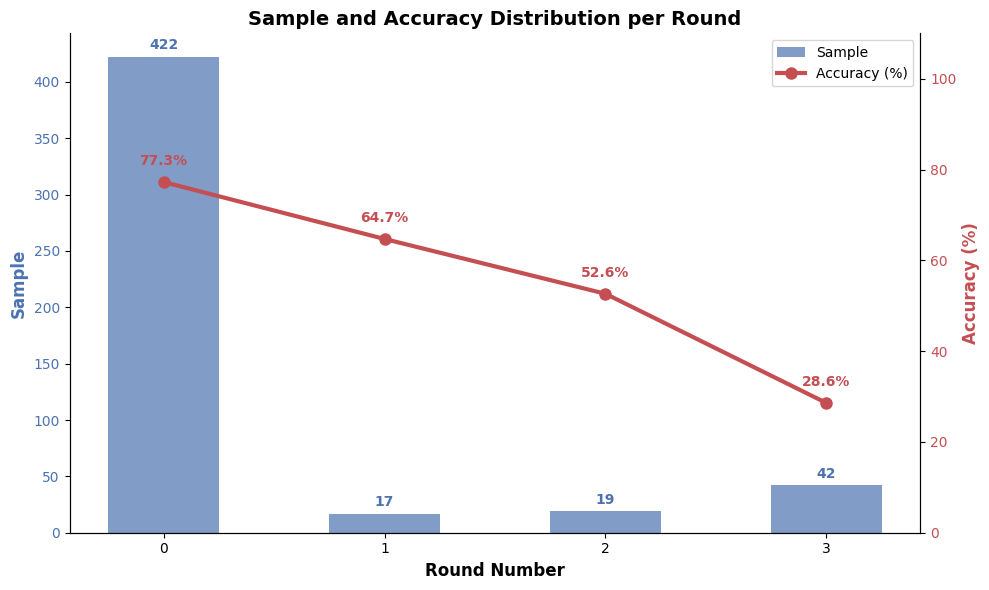

In [3]:
import json
import matplotlib.pyplot as plt

LABEL_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'
PRED_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'

try:
    # 1. Đọc dữ liệu
    with open(PRED_FILE, 'r', encoding='utf-8') as f:
        pred_data = json.load(f)
    with open(LABEL_FILE, 'r', encoding='utf-8') as f:
        label_data = json.load(f)

    if len(pred_data) != len(label_data):
        print(f"⚠️ Cảnh báo: Lệch số lượng! Pred: {len(pred_data)}, Label: {len(label_data)}.")

    # 2. Thống kê theo Round
    # Cấu trúc: {round_number: {'total': 0, 'correct': 0}}
    stats_by_round = {}

    for pred, lab in zip(pred_data, label_data):
        r_num = int(pred.get("round_number", 0))
        p_verdict = pred.get("final_verdict", "Unknown")
        l_verdict = lab.get("label", "Unknown")

        if r_num not in stats_by_round:
            stats_by_round[r_num] = {'total': 0, 'correct': 0}
        
        stats_by_round[r_num]['total'] += 1
        if p_verdict == l_verdict:
            stats_by_round[r_num]['correct'] += 1

    # 3. Trích xuất dữ liệu để vẽ
    # Sắp xếp các round theo thứ tự tăng dần (0, 1, 2, 3...)
    rounds = sorted(stats_by_round.keys())
    totals = [stats_by_round[r]['total'] for r in rounds]
    accuracies = [(stats_by_round[r]['correct'] / stats_by_round[r]['total']) * 100 for r in rounds]

    # 4. Vẽ biểu đồ Dual Y-axis
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Trục 1 (Bên trái): Biểu đồ cột cho Tổng số sample ---
    color_bar = '#4C72B0'
    bars = ax1.bar(rounds, totals, color=color_bar, alpha=0.7, width=0.5, label='Sample')
    ax1.set_xlabel('Round Number', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Sample', color=color_bar, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_bar)
    ax1.set_xticks(rounds) # Ép trục X hiển thị số nguyên
    
    # Thêm số lượng trên từng cột
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(totals)*0.01), 
                 f'{int(yval)}', ha='center', va='bottom', color=color_bar, fontweight='bold')

    # --- Trục 2 (Bên phải): Biểu đồ đường cho Độ chính xác ---
    ax2 = ax1.twinx() # Tạo trục Y thứ 2 dùng chung trục X
    color_line = '#C44E52'
    line = ax2.plot(rounds, accuracies, color=color_line, marker='o', linewidth=3, markersize=8, label='Accuracy (%)')
    ax2.set_ylabel('Accuracy (%)', color=color_line, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_line)
    ax2.set_ylim(0, 110) # Set max là 110 để có khoảng trống phía trên
    
    # Thêm số % trên từng điểm của đường
    for i, txt in enumerate(accuracies):
        ax2.text(rounds[i], txt + 3, f'{txt:.1f}%', ha='center', va='bottom', color=color_line, fontweight='bold')

    # --- Tinh chỉnh hiển thị ---
    plt.title('Sample and Accuracy Distribution per Round', fontsize=14, fontweight='bold')
    
    # Gộp legend của cả 2 trục
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    # Xoá viền trên cho thoáng
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Lỗi: {e}")

In [11]:
import json

INPUT_PATH = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/error_analysis_rerun.json'
with open(INPUT_PATH, 'r') as f:
    data = json.load(f)

new_data = sorted(data, key=lambda x: int(x["idx"]))

In [6]:
OUTPUT_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/error_analysis_sorted_rerun.json'
with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    json.dump(new_data, f, ensure_ascii=False, indent=4)

In [7]:
items = []
for d in new_data:
    try:
        item = {}
        item['idx'] = d['idx']
        item['error_analysis'] = d['error_analysis']
        items.append(item)
    except:
        pass

with open('/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/error_analysis_reduced_rerun.json', 'w') as f:
    json.dump(items, f, ensure_ascii=False, indent=4)

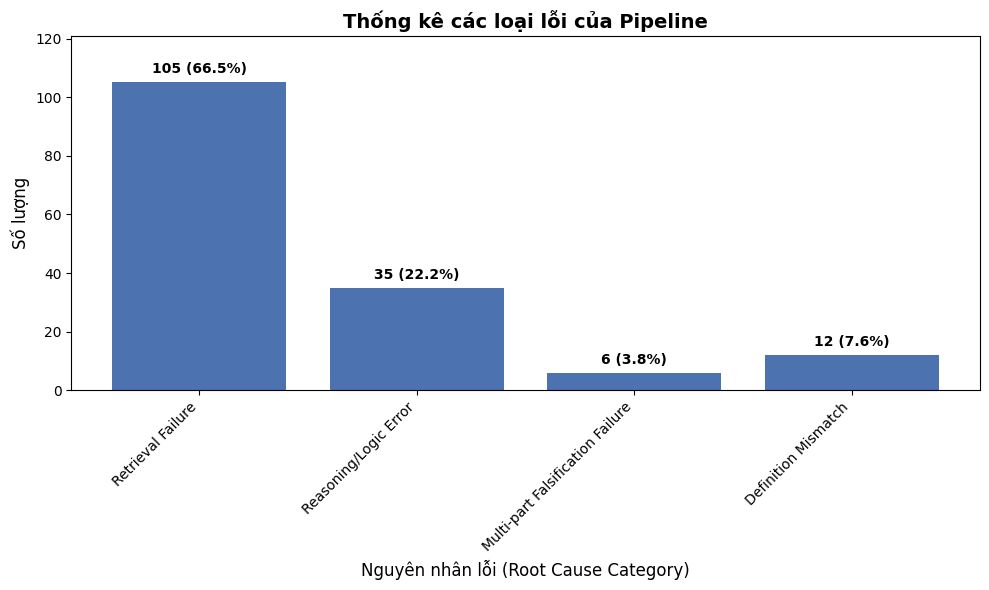

: 

In [ ]:
import json
import matplotlib.pyplot as plt

# 1. Thống kê dữ liệu
cnt = {}
with open('/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_errors.json', 'r') as f:
    new_data = json.load(f)
for d in new_data:
    try:
        category = d['error_analysis']['root_cause_category']
        cnt[category] = cnt.get(category, 0) + 1 
    except KeyError:
        pass

# 2. Tách Keys (Tên lỗi) và Values (Số lượng)
categories = list(cnt.keys())
counts = list(cnt.values())

# Tính tổng số lỗi để chia phần trăm
total_errors = sum(counts)

# 3. Vẽ biểu đồ cột (Bar Chart)
plt.figure(figsize=(10, 6)) 
bars = plt.bar(categories, counts, color='#4C72B0')

# Thêm số lượng và phần trăm hiển thị trên đỉnh mỗi cột
for bar in bars:
    yval = bar.get_height()
    # Tính % (nhân 100 để ra định dạng phần trăm)
    percentage = (yval / total_errors) * 100 
    
    # Tạo chuỗi text hiển thị, ví dụ: "105 (51.0%)"
    # Bạn có thể đổi .1f thành .0f nếu chỉ muốn lấy số nguyên (ví dụ: 51%)
    text_label = f'{int(yval)} ({percentage:.1f}%)'
    
    # Đẩy text lên trên đỉnh cột một khoảng bằng 2% chiều cao cột cao nhất để khỏi dính vào cột
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts) * 0.02), 
             text_label, ha='center', va='bottom', fontweight='bold')

# Nới trần trục Y lên thêm 15% để có chỗ chứa dòng text dài ở cột cao nhất
if counts:
    plt.ylim(0, max(counts) * 1.15)

# 4. Căn chỉnh text và tiêu đề
plt.title('Thống kê các loại lỗi của Pipeline', fontsize=14, fontweight='bold')
plt.xlabel('Nguyên nhân lỗi (Root Cause Category)', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)

# Xoay tên các nhãn lỗi 45 độ
plt.xticks(rotation=45, ha='right') 

plt.tight_layout() 
plt.show()

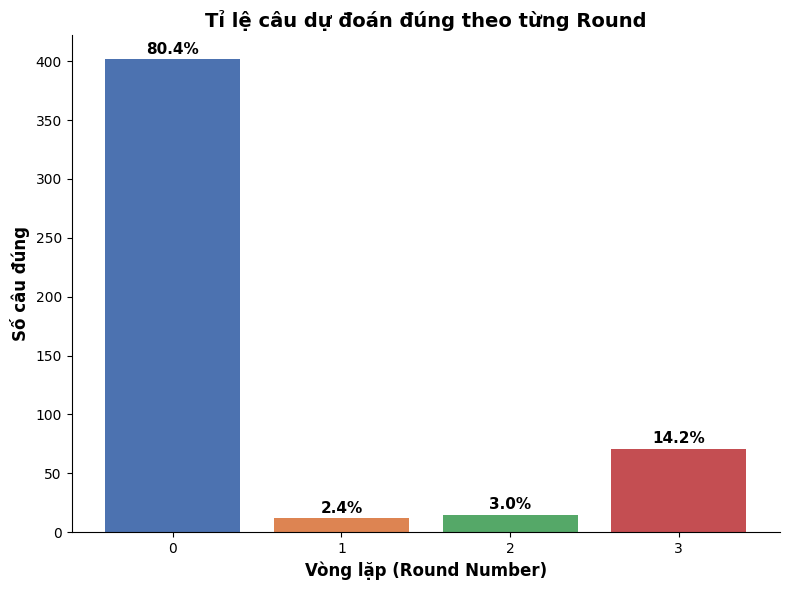

In [10]:
import json
import matplotlib.pyplot as plt

INPUT_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'

with open(INPUT_FILE, 'r') as f:
    pred_data = json.load(f)

# Thống kê số câu đúng theo round_number
cnt = {}
for l in pred_data:
    # Lưu ý: Nếu file json chứa cả câu sai, bạn cần thêm điều kiện lọc ở đây. 
    # Ví dụ: if l['predicted_label'] == l['true_label']:
    
    round_num = int(l['round_number'])
    # Giới hạn trục ngang là 3 (0, 1, 2, 3 -> tương ứng 4 cột)
    if round_num <= 3:
        cnt[round_num] = cnt.get(round_num, 0) + 1

# Đảm bảo trục x có đủ các giá trị từ 0 đến 3 ngay cả khi count = 0
rounds = [0, 1, 2, 3]
counts = [cnt.get(r, 0) for r in rounds]

# Thiết lập 4 màu khác nhau cho 4 cột
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Khởi tạo biểu đồ
plt.figure(figsize=(8, 6))
bars = plt.bar(rounds, counts, color=colors)

# Hiển thị phần trăm (trên tổng số 500) ở trên đỉnh mỗi cột
TOTAL_SAMPLES = 500
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / TOTAL_SAMPLES) * 100
    
    # Định dạng vị trí và text
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, 
             f'{percentage:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Cài đặt nhãn và tiêu đề
plt.xticks(rounds) # Ép trục x chỉ hiển thị số nguyên 0, 1, 2, 3
plt.xlim(-0.6, 3.6) # Giới hạn không gian ngang
plt.ylim(0, max(counts) + 20) # Thêm một chút khoảng trống phía trên cột để text không bị cắt

plt.xlabel('Vòng lặp (Round Number)', fontsize=12, fontweight='bold')
plt.ylabel('Số câu đúng', fontsize=12, fontweight='bold')
plt.title('Tỉ lệ câu dự đoán đúng theo từng Round', fontsize=14, fontweight='bold')

# Bỏ viền trên và viền phải cho biểu đồ đẹp hơn (tuỳ chọn)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Đang load dữ liệu Ground Truth...
Đang load và đối chiếu dữ liệu Prediction...
Đang vẽ Confusion Matrix...


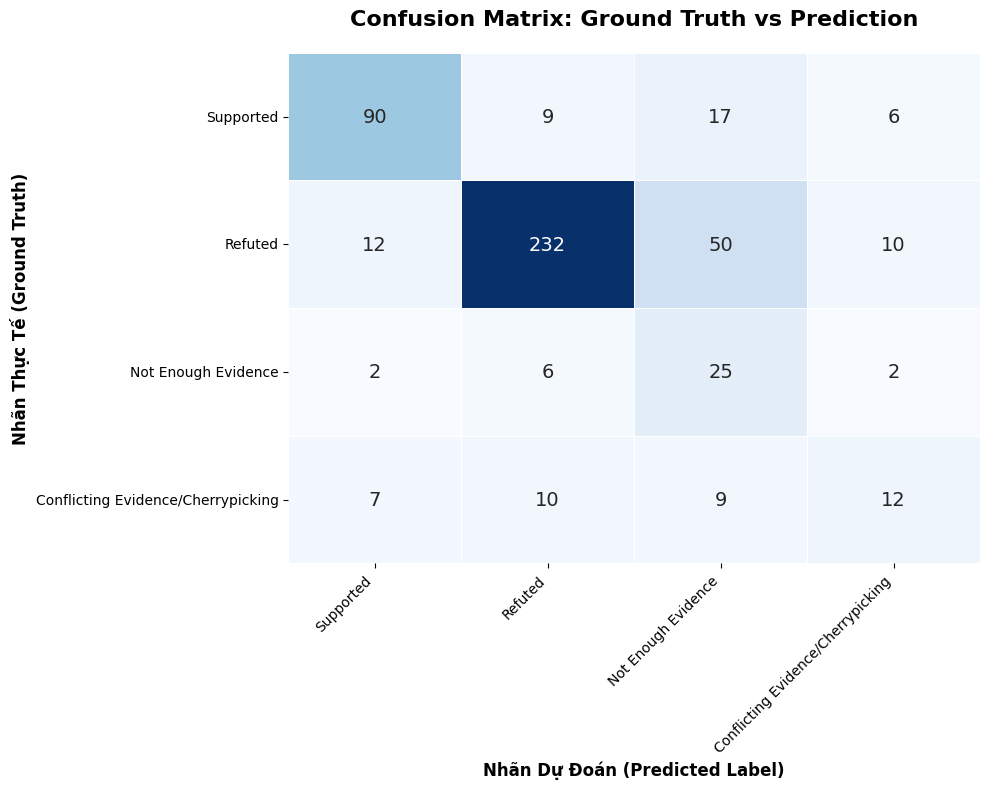

In [9]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
from collections import defaultdict

# --- CẤU HÌNH ĐƯỜNG DẪN ---
LABEL_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'
PRED_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'

def analyze_and_draw_confusion_matrix():
    # 1. Load Ground Truth vào Dictionary
    print("Đang load dữ liệu Ground Truth...")
    label_dict = {}
    with open(LABEL_FILE, 'r', encoding='utf-8') as f:
        labels_raw = json.load(f)
        for i, item in enumerate(labels_raw):
            lab_id = str(i)
            label_dict[lab_id] = item.get("label", "Unknown")

    # Khởi tạo các biến lưu trữ
    y_true = []
    y_pred = []

    # 2. Đọc file Prediction và Map dữ liệu
    print("Đang load và đối chiếu dữ liệu Prediction...")
    with open(PRED_FILE, 'r', encoding='utf-8') as f:
        pred_data = json.load(f)
    for pred in pred_data:
        idx = str(pred.get("idx"))
        if idx not in label_dict:
            continue # Bỏ qua nếu không tìm thấy ID trong file nhãn
            
        t_label = label_dict[idx] # Ground Truth Label
        p_label = pred.get("final_verdict", "Unknown") # Predicted Label
        
        # Lưu mảng 1D để vẽ ma trận
        y_true.append(t_label)
        y_pred.append(p_label)

    # ==========================================
    # 4. VẼ CONFUSION MATRIX
    # ==========================================
    print("Đang vẽ Confusion Matrix...")
    
    # Lấy danh sách tất cả các nhãn (để phòng trường hợp model hallucinate ra nhãn lạ)
    labels = sorted(list(set(y_true + y_pred)))
    
    # Sắp xếp lại thứ tự nhãn cho logic hơn (theo chuẩn AVeriTeC) nếu có
    standard_order = ["Supported", "Refuted", "Not Enough Evidence", "Conflicting Evidence/Cherrypicking"]
    ordered_labels = [l for l in standard_order if l in labels]
    # Thêm các nhãn lạ mà model tự đẻ ra (nếu có) vào cuối
    # ordered_labels += [l for l in labels if l not in standard_order]

    # Tính toán ma trận
    cm = confusion_matrix(y_true, y_pred, labels=ordered_labels)

    # Chỉnh kích thước form vẽ
    plt.figure(figsize=(10, 8))
    
    # Vẽ Heatmap bằng Seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=ordered_labels, 
                yticklabels=ordered_labels,
                linewidths=.5, cbar=False, annot_kws={"size": 14})

    # Căn chỉnh hiển thị
    plt.title('Confusion Matrix: Ground Truth vs Prediction', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Nhãn Thực Tế (Ground Truth)', fontsize=12, fontweight='bold')
    plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
    
    # Xoay nhãn trục X để không bị dính chữ
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

# Chạy code
analyze_and_draw_confusion_matrix()

In [2]:
PRED_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerun3.jsonl'
GROUND_TRUTH_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'
import json
total = 0
acc = 0
pred_items = []
ground_truth_items = []
with open(GROUND_TRUTH_FILE, 'r') as f:
    ground_truth_items = json.load(f)
with open(PRED_FILE, 'r') as f:
    for line in f:
        pred_item = json.loads(line)
        if pred_item['final_verdict'] == ground_truth_items[int(pred_item["idx"])]["label"]:
            acc += 1
        total += 1

print(acc/total, acc/500)

0.15873015873015872 0.04


In [19]:
acc, total

(15, 117)

In [2]:
PRED_0 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results.jsonl'
PRED_1 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn.jsonl'
PRED_2 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn2.jsonl'
PRED_3 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerun3.jsonl'
LABEL = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'
import json

pred_0 = {}
with open(PRED_0, 'r') as f:
    for line in f:
        item = json.loads(line)
        pred_0[item['idx']] = item

pred_1 = {}
with open(PRED_1, 'r') as f:
    for line in f:
        item = json.loads(line)
        pred_1[item['idx']] = item

pred_2 = {}
idxs = []
with open(PRED_2, 'r') as f:
    for line in f:
        item = json.loads(line)
        pred_2[item['idx']] = item
        idxs.append(int(item['idx']))

pred_3 = {}
idxs = []
with open(PRED_3, 'r') as f:
    for line in f:
        item = json.loads(line)
        pred_3[item['idx']] = item
        idxs.append(int(item['idx']))

idxs = sorted(idxs)

lbs = []
with open(LABEL, 'r') as f:
    lbs = json.load(f)

results = []
for i in idxs:
    item = {}
    item['idx'] = i
    item['claim'] = lbs[i]['claim']
    item['label'] = lbs[i]['label']
    item['justification'] = lbs[i]['justification']
    item['questions'] = lbs[i]['questions']

    if str(i) in pred_0:
        pred_0_item = {}
        it = pred_0[str(i)]
        pred_0_item['justification'] = it['final_justification']
        pred_0_item['verdict'] = it['final_verdict']
        item['initial_predict'] = pred_0_item
    
    if str(i) in pred_1:
        pred_1_item = {}
        it = pred_1[str(i)]
        pred_1_item['justification'] = it['final_justification']
        pred_1_item['verdict'] = it['final_verdict']
        item['first_predict'] = pred_1_item

    if str(i) in pred_2:
        pred_2_item = {}
        it = pred_2[str(i)]
        pred_2_item['justification'] = it['final_justification']
        pred_2_item['verdict'] = it['final_verdict']
        item['second_predict'] = pred_2_item

    if str(i) in pred_3:
        pred_3_item = {}
        it = pred_3[str(i)]
        pred_3_item['justification'] = it['final_justification']
        pred_3_item['verdict'] = it['final_verdict']
        item['third_predict'] = pred_3_item
    results.append(item)

OUTPUT_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/compare_results.json'
with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

In [3]:
PRED_0 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results.jsonl'
PRED_1 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn.jsonl'
PRED_2 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn2.jsonl'
LABEL = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'
import json

pred_0 = {}
with open(PRED_0, 'r') as f:
    for line in f:
        item = json.loads(line)
        pred_0[item['idx']] = item

pred_1 = {}
with open(PRED_1, 'r') as f:
    for line in f:
        item = json.loads(line)
        pred_1[item['idx']] = item

pred_2 = {}
with open(PRED_2, 'r') as f:
    for line in f:
        item = json.loads(line)
        pred_2[item['idx']] = item

lbs = []
with open(LABEL, 'r') as f:
    lbs = json.load(f)

results = []
for i in range(500):
    lb_item = lbs[i]
    if str(i) in pred_2:
        results.append(pred_2[str(i)])
    elif str(i) in pred_1:
        results.append(pred_1[str(i)])
    else:
        results.append(pred_0[str(i)])


OUTPUT_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'
with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

In [25]:
import json

# --- ĐƯỜNG DẪN FILE ---
PRED_0 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results.jsonl'
PRED_1 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn.jsonl'
PRED_2 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn2.jsonl'
LABEL_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'

ERROR_0 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/error_analysis_reduced.json'
ERROR_1 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/error_analysis_reduced_rerun.json'

OUTPUT_PRED = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'
OUTPUT_ERR = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_errors.json'

# --- 1. ĐỌC DỮ LIỆU ---
def load_jsonl(filepath):
    data = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            data[str(item['idx'])] = item
    return data

pred_0 = load_jsonl(PRED_0)
pred_1 = load_jsonl(PRED_1)
pred_2 = load_jsonl(PRED_2)

with open(LABEL_FILE, 'r', encoding='utf-8') as f:
    lbs = json.load(f)

# --- 2. XỬ LÝ PREDICTION CUỐI CÙNG ---
final_preds = []
correct_indices = set() # Tập hợp lưu trữ index của các câu ĐÃ ĐOÁN ĐÚNG

for i in range(500):
    idx_str = str(i)
    
    # Lấy prediction mới nhất
    if idx_str in pred_2:
        current_pred = pred_2[idx_str]
    elif idx_str in pred_1:
        current_pred = pred_1[idx_str]
    else:
        current_pred = pred_0[idx_str]
        
    final_preds.append(current_pred)
    
    # KIỂM TRA ĐÚNG/SAI: So sánh dự đoán với nhãn thực tế
    p_verdict = current_pred.get("final_verdict")
    l_verdict = lbs[i].get("label")
    
    if p_verdict == l_verdict:
        correct_indices.add(idx_str) # Nếu đúng, đưa vào set để filter log lỗi sau

# Lưu final_results.json
# with open(OUTPUT_PRED, 'w', encoding='utf-8') as f:
#     json.dump(final_preds, f, ensure_ascii=False, indent=4)


# --- 3. XỬ LÝ LOG LỖI VÀ LỌC CÁC CÂU ĐÃ ĐÚNG ---
err_0 = {}
with open(ERROR_0, 'r', encoding='utf-8') as f:
    for it in json.load(f):
        err_0[str(it['idx'])] = it

err_1 = {}
with open(ERROR_1, 'r', encoding='utf-8') as f:
    for it in json.load(f):
        err_1[str(it['idx'])] = it

final_errors = []
for i in range(500):
    idx_str = str(i)
    
    # NẾU CÂU NÀY ĐÃ NẰM TRONG TẬP HỢP "ĐOÁN ĐÚNG" THÌ BỎ QUA, KHÔNG GHI VÀO LOG LỖI
    if idx_str in correct_indices:
        continue
        
    # Nếu vẫn sai, lấy log lỗi mới nhất có thể
    if idx_str in err_0:
        item = err_0[idx_str]
        if idx_str in err_1:
            item = err_1[idx_str]
        final_errors.append(item)

# Lưu final_errors.json
with open(OUTPUT_ERR, 'w', encoding='utf-8') as f:
    json.dump(final_errors, f, ensure_ascii=False, indent=4)

print(f"Đã xử lý xong! Lọc bỏ thành công {len(correct_indices)} câu đúng khỏi log lỗi.")

Đã xử lý xong! Lọc bỏ thành công 341 câu đúng khỏi log lỗi.


In [3]:
import json
from pathlib import Path

def analyze_knowledge_store(base_dir_path):
    splits = ['dev', 'test']
    
    # Khởi tạo cấu trúc lưu trữ dữ liệu
    stats = {
        split: {
            'gold_counts_per_file': [],  # Lưu số lượng item gold của từng file
            'sentence_counts': [],       # Lưu độ dài list url2text của từng item gold
            'empty_url2text_items': []   # "Góc" lưu các item gold có url2text rỗng
        } for split in splits
    }
    
    base_dir = Path(base_dir_path)
    
    for split in splits:
        split_dir = base_dir / split
        if not split_dir.exists():
            print(f"[!] Không tìm thấy thư mục: {split_dir}")
            continue
            
        # Duyệt qua tất cả các file .json trong thư mục split
        for file_path in split_dir.glob("*.json"):
            gold_count_in_file = 0
            
            with open(file_path, 'r', encoding='utf-8') as f:
                for line_idx, line in enumerate(f):
                    line = line.strip()
                    if not line:
                        continue
                        
                    try:
                        item = json.loads(line)
                    except json.JSONDecodeError:
                        print(f"Lỗi parse JSON tại file {file_path.name}, dòng {line_idx}")
                        continue
                        
                    # Kiểm tra type
                    if item.get("type") == "gold":
                        gold_count_in_file += 1
                        
                        # Lấy url2text, nếu không có key này thì mặc định là list rỗng
                        url2text = item.get("url2text", [])
                        
                        if len(url2text) == 0:
                            # Lưu vào "1 góc" để sau này inspect
                            stats[split]['empty_url2text_items'].append({
                                "file_name": file_path.name,
                                "line_index": line_idx,
                                "claim_id": item.get("claim_id", "Unknown") # Lấy thêm ID nếu có
                            })
                        else:
                            # Có phần tử thì đếm số lượng câu (độ dài list)
                            stats[split]['sentence_counts'].append(len(url2text))
                    else:
                        # Gặp type khác 'gold', ngắt vòng lặp đọc file hiện tại
                        break
                        
            # Lưu tổng số gold của file này lại
            stats[split]['gold_counts_per_file'].append(gold_count_in_file)

    # --- IN KẾT QUẢ THỐNG KÊ ---
    def print_metrics(title, data_list):
        if not data_list:
            print(f"  {title}: Không có dữ liệu")
            return
        avg_val = sum(data_list) / len(data_list)
        max_val = max(data_list)
        print(f"  {title}: Trung bình = {avg_val:.2f} | Tối đa = {max_val}")

    print("\n" + "="*60)
    print(" BÁO CÁO THỐNG KÊ KNOWLEDGE STORE")
    print("="*60)
    
    all_gold_counts = []
    all_sentence_counts = []
    total_empty_items = 0
    
    # 1. Thống kê theo từng split
    for split in splits:
        print(f"\n📁 SPLIT: {split.upper()}")
        
        gold_list = stats[split]['gold_counts_per_file']
        sent_list = stats[split]['sentence_counts']
        empty_count = len(stats[split]['empty_url2text_items'])
        
        print_metrics("Số item GOLD / file", gold_list)
        print_metrics("Số câu trong url2text / item GOLD", sent_list)
        print(f"  Số item GOLD bị rỗng url2text: {empty_count}")
        
        # Gom dữ liệu để tính tổng hợp
        all_gold_counts.extend(gold_list)
        all_sentence_counts.extend(sent_list)
        total_empty_items += empty_count
        
    # 2. Thống kê tổng hợp cả 3 split
    print("\n" + "="*60)
    print(" TỔNG HỢP CẢ 3 SPLIT (TRAIN, DEV, TEST)")
    print("="*60)
    print_metrics("Số item GOLD / file", all_gold_counts)
    print_metrics("Số câu trong url2text / item GOLD", all_sentence_counts)
    print(f"  Tổng số item GOLD bị rỗng url2text: {total_empty_items}")
    
    return stats

# --- CÁCH SỬ DỤNG ---
if __name__ == "__main__":
    # Thay bằng đường dẫn thực tế của bạn
    KNOWLEDGE_STORE_PATH = "/Users/mvk/FinalProject/FEVER-8-Shared-Task/knowledge_store" 
    
    # Chạy hàm và nhận lại cục data 'stats'
    results = analyze_knowledge_store(KNOWLEDGE_STORE_PATH)
    
    # Nếu bạn muốn xem danh sách các item bị rỗng url2text trong tập dev chẳng hạn:
    # print("\nChi tiết các item rỗng trong tập DEV:")
    # print(results['dev']['empty_url2text_items'][:5]) # In thử 5 cái đầu tiên


 BÁO CÁO THỐNG KÊ KNOWLEDGE STORE

📁 SPLIT: DEV
  Số item GOLD / file: Trung bình = 2.19 | Tối đa = 8
  Số câu trong url2text / item GOLD: Trung bình = 157.07 | Tối đa = 17712
  Số item GOLD bị rỗng url2text: 442

📁 SPLIT: TEST
  Số item GOLD / file: Trung bình = 2.19 | Tối đa = 12
  Số câu trong url2text / item GOLD: Trung bình = 58.73 | Tối đa = 3153
  Số item GOLD bị rỗng url2text: 2142

 TỔNG HỢP CẢ 3 SPLIT (TRAIN, DEV, TEST)
  Số item GOLD / file: Trung bình = 2.19 | Tối đa = 12
  Số câu trong url2text / item GOLD: Trung bình = 77.85 | Tối đa = 17712
  Tổng số item GOLD bị rỗng url2text: 2584


In [4]:
import json

# --- ĐƯỜNG DẪN FILE ---
PRED_0 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results.jsonl'
PRED_1 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn.jsonl'
PRED_2 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerurn2.jsonl'
PRED_3 = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/dev_results_rerun3.jsonl'
LABEL_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'

OUTPUT_PRED = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'
FALSE_OUTPUT_PRED = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/false_results.json'
# --- 1. ĐỌC DỮ LIỆU ---
def load_jsonl(filepath):
    data = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            item = json.loads(line)
            data[str(item['idx'])] = item
    return data

pred_0 = load_jsonl(PRED_0)
pred_1 = load_jsonl(PRED_1)
pred_2 = load_jsonl(PRED_2)
pred_3 = load_jsonl(PRED_3)

with open(LABEL_FILE, 'r', encoding='utf-8') as f:
    lbs = json.load(f)

# --- 2. XỬ LÝ PREDICTION CUỐI CÙNG ---
final_preds = []
correct_indices = set() # Tập hợp lưu trữ index của các câu ĐÃ ĐOÁN ĐÚNG
false_preds = []
for i in range(500):
    idx_str = str(i)
    
    # Lấy prediction mới nhất
    if idx_str in pred_3:
        current_pred = pred_3[idx_str]
    elif idx_str in pred_2:
        current_pred = pred_2[idx_str]
    elif idx_str in pred_1:
        current_pred = pred_1[idx_str]
    else:
        current_pred = pred_0[idx_str]
        
    final_preds.append(current_pred)
    
    # KIỂM TRA ĐÚNG/SAI: So sánh dự đoán với nhãn thực tế
    p_verdict = current_pred.get("final_verdict")
    l_verdict = lbs[i].get("label")
    
    if p_verdict == l_verdict:
        correct_indices.add(idx_str) # Nếu đúng, đưa vào set để filter log lỗi sau
    else:
        false_preds.append(current_pred)
    

# Lưu final_results.json
with open(OUTPUT_PRED, 'w', encoding='utf-8') as f:
    json.dump(final_preds, f, ensure_ascii=False, indent=4)

with open(FALSE_OUTPUT_PRED, 'w', encoding='utf-8') as f:
    json.dump(false_preds, f, ensure_ascii=False, indent=4)

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
# Created by zd302 at 12/01/2025
import csv
import json

def convert(file_json):
    with open(file_json) as f:
        samples = json.load(f)

    new_samples = []
    for i, sample in enumerate(samples):
        claim = sample['claim']
        label = sample['pred_label']
        prediction_evidence = ""
        for src_qa in sample['evidence']:
            prediction_evidence += src_qa["question"] + "\t\t\n" + src_qa["answer"] + "\t\t\n\n"
        #
        new_samples.append([i, claim, prediction_evidence, label, 'pred'])

    with open("submission.csv", mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["id", "claim", "evi", "label", "split"])  # Write header
        writer.writerows(new_samples)

    print("{} have been converted to .csv".format(file_json))


filename = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/test.json'
convert(filename)

Đang load dữ liệu Ground Truth...
Đang load và đối chiếu dữ liệu để tính Accuracy...
Đang vẽ biểu đồ Accuracy...


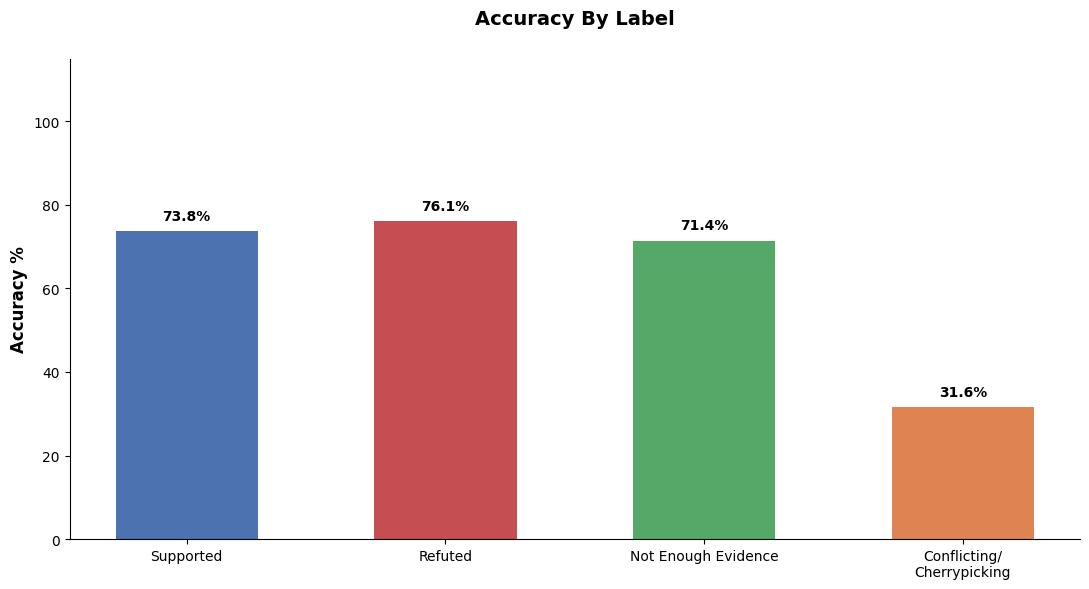

In [8]:
import json
import matplotlib.pyplot as plt

# --- CẤU HÌNH ĐƯỜNG DẪN (Giữ nguyên như code Confusion Matrix của bạn) ---
LABEL_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'
PRED_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'

# 1. Load Ground Truth vào Dictionary theo chỉ mục chuỗi
print("Đang load dữ liệu Ground Truth...")
label_dict = {}
with open(LABEL_FILE, 'r', encoding='utf-8') as f:
    labels_raw = json.load(f)
    for i, item in enumerate(labels_raw):
        lab_id = str(i)
        label_dict[lab_id] = item.get("label", "Unknown")

# Định nghĩa các nhãn chuẩn để thống kê
CLASSES = ["Supported", "Refuted", "Not Enough Evidence", "Conflicting Evidence/Cherrypicking"]

# Khởi tạo các bộ đếm thống kê
total_samples = 0
total_correct = 0
class_totals = {c: 0 for c in CLASSES}
class_correct = {c: 0 for c in CLASSES}

# 2. Đọc file Prediction và map chính xác để tính toán Accuracy
print("Đang load và đối chiếu dữ liệu để tính Accuracy...")
with open(PRED_FILE, 'r', encoding='utf-8') as f:
    pred_data = json.load(f)

for pred in pred_data:
    idx = str(pred.get("idx"))
    if idx not in label_dict:
        continue  # Bỏ qua nếu không tìm thấy ID khớp với file gốc
        
    t_label = label_dict[idx]                       # Nhãn thực tế từ file gốc
    p_label = pred.get("final_verdict", "Unknown")  # Nhãn dự đoán từ Agent
    
    # Chỉ thống kê các nhãn hợp lệ nằm trong danh mục chuẩn định nghĩa trước
    if t_label in class_totals:
        total_samples += 1
        class_totals[t_label] += 1
        
        if t_label == p_label:
            total_correct += 1
            class_correct[t_label] += 1

# 3. Tính toán tỷ lệ phần trăm chính xác (Accuracy %)
categories = []
accuracies = []

for c in CLASSES:
    categories.append(c)
    acc = (class_correct[c] / class_totals[c] * 100) if class_totals[c] > 0 else 0
    accuracies.append(acc)

# Xuống dòng cho nhãn quá dài để tránh đè chữ trên trục hoành
x_labels = [c if c != 'Conflicting Evidence/Cherrypicking' else 'Conflicting/\nCherrypicking' for c in categories]

# 4. VẼ BIỂU ĐỒ THANH (BAR PLOT)
print("Đang vẽ biểu đồ Accuracy...")
plt.figure(figsize=(11, 6))

# Bảng màu: Cột tổng quan màu xám đậm chuyên nghiệp, các cột sau theo màu chỉ định riêng biệt
colors = ['#4C72B0', '#C44E52', '#55A868', '#DD8452']
bars = plt.bar(x_labels, accuracies, color=colors[:len(categories)], width=0.55)

# Hiển thị text thông số kép (Phần trăm + Phân số thực tế) trên đỉnh mỗi cột
for bar, cat in zip(bars, categories):
    yval = bar.get_height()
    
    # Lấy chuỗi biểu thị phân số tương ứng
    # if cat == 'Overall':
    #     subtext = f"({total_correct}/{total_samples})"
    # else:
    #     subtext = f"({class_correct[cat]}/{class_totals[cat]})"
        
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, 
             f'{yval:.1f}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Cấu hình thẩm mỹ cho biểu đồ
plt.ylabel('Accuracy %', fontsize=12, fontweight='bold')
plt.title('Accuracy By Label', fontsize=14, fontweight='bold', pad=25)
plt.ylim(0, 115)  # Tạo khoảng trống phía trên đỉnh cột để text không bị khuất

# Loại bỏ viền thừa (top và right) giúp đồ họa thoáng và hiện đại hơn
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Đang vẽ Confusion Matrix...


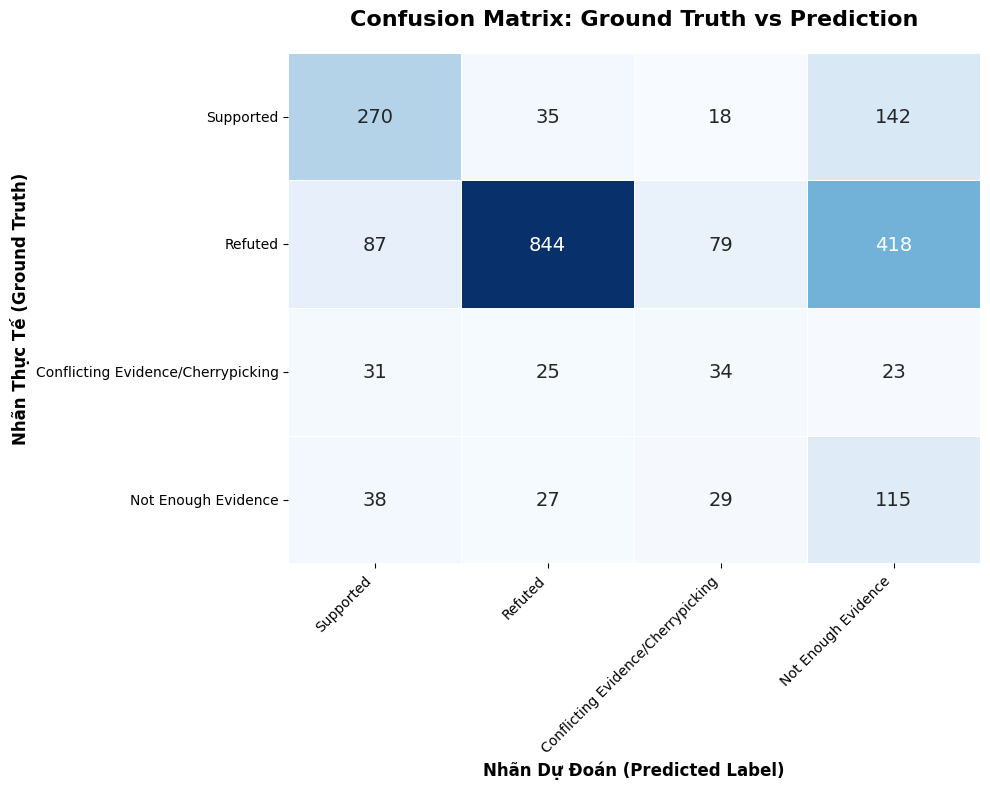

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def draw_confusion_matrix():
    # 1. Định nghĩa các nhãn chuẩn theo thứ tự (tương ứng Loại 1, 2, 3, 4)
    ordered_labels = [
        "Supported", 
        "Refuted", 
        "Conflicting Evidence/Cherrypicking",
        "Not Enough Evidence", 
    ]

    cm = np.array([
        [270,  35,  18, 142],
        [ 87, 844,  79, 418],
        [ 31,  25,  34,  23],
        [ 38,  27,  29, 115]
    ])

    # ==========================================
    # 3. VẼ CONFUSION MATRIX
    # ==========================================
    print("Đang vẽ Confusion Matrix...")
    
    # Chỉnh kích thước form vẽ
    plt.figure(figsize=(10, 8))
    
    # Vẽ Heatmap bằng Seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=ordered_labels, 
                yticklabels=ordered_labels,
                linewidths=.5, cbar=False, annot_kws={"size": 14})

    # Căn chỉnh hiển thị
    plt.title('Confusion Matrix: Ground Truth vs Prediction', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Nhãn Thực Tế (Ground Truth)', fontsize=12, fontweight='bold')
    plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')
    
    # Xoay nhãn trục X để không bị dính chữ
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

# Chạy code
draw_confusion_matrix()

Đang vẽ biểu đồ Accuracy...


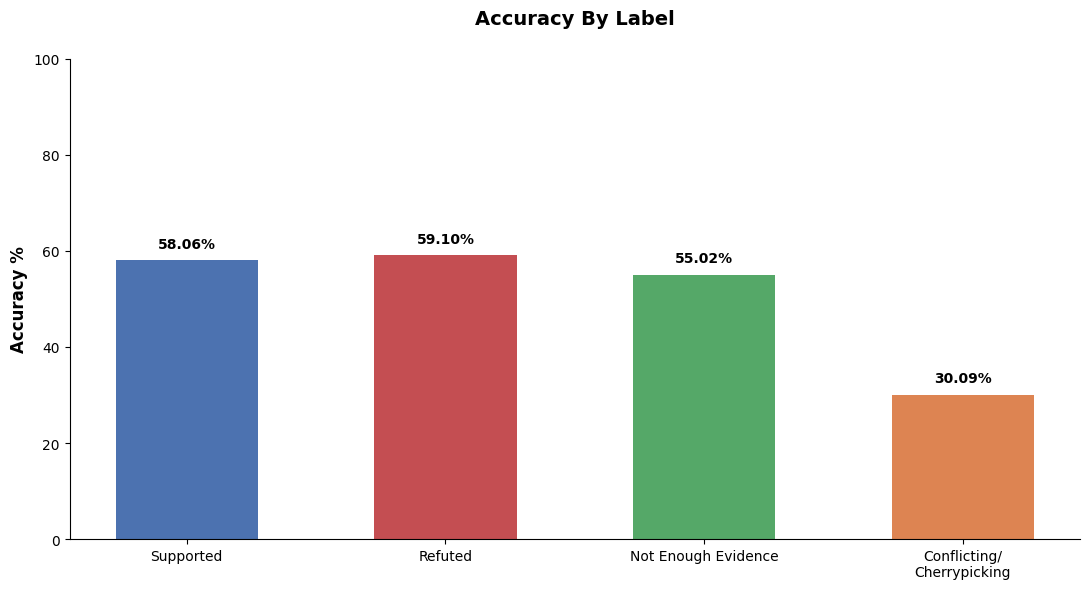

In [ ]:
import matplotlib.pyplot as plt

def draw_accuracy_chart():
    CLASSES = [
        "Supported", 
        "Refuted", 
        "Not Enough Evidence", 
        "Conflicting Evidence/Cherrypicking"
    ]

    class_totals = {
        "Supported": 465, 
        "Refuted": 1428, 
        "Not Enough Evidence": 209, 
        "Conflicting Evidence/Cherrypicking": 113
    }

    class_cor = {
        "Supported": 270, 
        "Refuted": 844, 
        "Not Enough Evidence": 115, 
        "Conflicting Evidence/Cherrypicking": 34
    }

    categories = []
    accuracies = []

    for c in CLASSES:
        categories.append(c)
        acc = (class_cor[c] / class_totals[c] * 100) if class_totals[c] > 0 else 0
        accuracies.append(acc)

    # Xuống dòng cho nhãn quá dài để tránh đè chữ trên trục hoành
    x_labels = [c if c != 'Conflicting Evidence/Cherrypicking' else 'Conflicting/\nCherrypicking' for c in categories]

    # 3. VẼ BIỂU ĐỒ THANH (BAR PLOT)
    print("Đang vẽ biểu đồ Accuracy...")
    plt.figure(figsize=(11, 6))

    # Bảng màu: Các cột theo màu chỉ định riêng biệt
    colors = ['#4C72B0', '#C44E52', '#55A868', '#DD8452']
    bars = plt.bar(x_labels, accuracies, color=colors[:len(categories)], width=0.55)

    # Hiển thị text thông số trên đỉnh mỗi cột
    for bar, cat in zip(bars, categories):
        yval = bar.get_height()
        
        # Bỏ comment cụm dưới nếu bạn muốn hiện cả phân số (VD: 270/465) ngay dưới phần trăm
        # subtext = f"\n({class_correct[cat]}/{class_totals[cat]})"
        # plt.text(bar.get_x() + bar.get_width()/2, yval + 2, 
        #          f'{yval:.2f}%{subtext}', 
        #          ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        # Hiện chỉ phần trăm (2 chữ số thập phân)
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, 
                 f'{yval:.2f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

    # Cấu hình thẩm mỹ cho biểu đồ
    plt.ylabel('Accuracy %', fontsize=12, fontweight='bold')
    plt.title('Accuracy By Label', fontsize=14, fontweight='bold', pad=25)
    plt.ylim(0, 100)  # Để 100 hoặc 115 tùy theo bạn muốn khoảng trống phía trên đỉnh cột nhiều hay ít

    # Loại bỏ viền thừa (top và right) giúp đồ họa thoáng và hiện đại hơn
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

# Chạy code
draw_accuracy_chart()

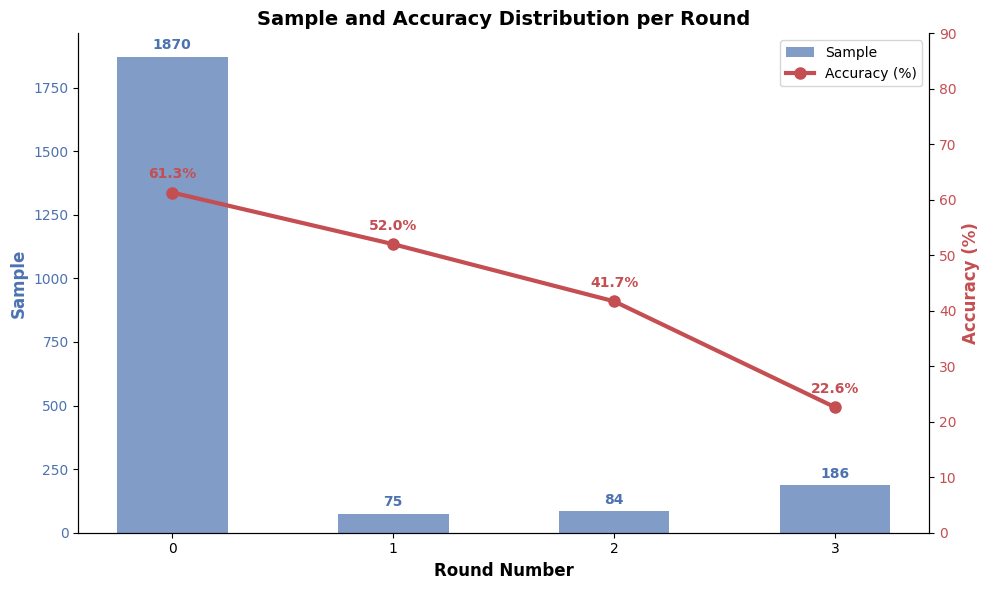

In [ ]:
import matplotlib.pyplot as plt

def draw_round_stats():
    rounds = [0, 1, 2, 3]
    
    # 2. Vẽ biểu đồ Dual Y-axis
    fig, ax1 = plt.subplots(figsize=(10, 6))
    totals = [1870, 75, 84, 186]
    accs = [61.3, 52.0, 41.7, 22.6]
    # --- Trục 1 (Bên trái): Biểu đồ cột cho Tổng số sample ---
    color_bar = '#4C72B0'
    bars = ax1.bar(rounds, totals, color=color_bar, alpha=0.7, width=0.5, label='Sample')
    ax1.set_xlabel('Round Number', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Sample', color=color_bar, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_bar)
    ax1.set_xticks(rounds) 
    
    # Thêm số lượng trên từng cột
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(totals)*0.01), 
                 f'{int(yval)}', ha='center', va='bottom', color=color_bar, fontweight='bold')

    # --- Trục 2 (Bên phải): Biểu đồ đường cho Độ chính xác ---
    ax2 = ax1.twinx() 
    color_line = '#C44E52'
    line = ax2.plot(rounds, accs, color=color_line, marker='o', linewidth=3, markersize=8, label='Accuracy (%)')
    ax2.set_ylabel('Accuracy (%)', color=color_line, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_line)
    
    # Hạ ylim xuống một chút cho vừa vặn với đường line mới thấp hơn
    ax2.set_ylim(0, 90) 
    
    # Thêm số % trên từng điểm của đường
    for i, txt in enumerate(accuracies):
        ax2.text(rounds[i], txt + 2, f'{txt:.1f}%', ha='center', va='bottom', color=color_line, fontweight='bold')

    # --- Tinh chỉnh hiển thị ---
    plt.title('Sample and Accuracy Distribution per Round', fontsize=14, fontweight='bold')
    
    # Gộp legend của cả 2 trục
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')
    
    # Xoá viền trên cho thoáng
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    plt.tight_layout()
    plt.show()

draw_round_stats()

In [5]:
import json

# --- CẤU HÌNH ĐƯỜNG DẪN ---
LABEL_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/dev.json'
PRED_FILE = '/Users/mvk/FinalProject/FEVER-8-Shared-Task/data_store/averitec/results/final_results.json'

# 1. Load Ground Truth vào Dictionary theo chỉ mục chuỗi
print("Đang load dữ liệu Ground Truth...")
label_dict = {}
with open(LABEL_FILE, 'r', encoding='utf-8') as f:
    labels_raw = json.load(f)
    for i, item in enumerate(labels_raw):
        lab_id = str(i)
        label_dict[lab_id] = item.get("label", "Unknown")

# 2. Đọc file Prediction và lọc ra idx thoả mãn điều kiện
print("Đang đối chiếu dữ liệu để lọc idx...")

# Khởi tạo list để lưu các idx thoả mãn
filtered_idxs = []

with open(PRED_FILE, 'r', encoding='utf-8') as f:
    pred_data = json.load(f)

for pred in pred_data:
    idx = str(pred.get("idx"))
    
    if idx not in label_dict:
        continue  # Bỏ qua nếu không tìm thấy ID khớp với file gốc
        
    t_label = label_dict[idx]                       # Nhãn thực tế từ file gốc
    p_label = pred.get("final_verdict", "Unknown")  # Nhãn dự đoán từ Agent
    
    # Lấy giá trị round_number (giả sử nếu không có key này thì mặc định là 0)
    round_number = pred.get("round_number", 0)
    
    # Điều kiện lọc: Dự đoán đúng VÀ round_number khác 0
    if t_label == p_label and round_number != 0 and 'Refute' in t_label:
        filtered_idxs.append(idx)

# 3. Hiển thị kết quả
print(f"Tổng số mẫu dự đoán ĐÚNG và có round_number KHÁC 0 là: {len(filtered_idxs)}")
print("Danh sách các idx đó:")
print(filtered_idxs)

# Nếu bạn muốn ghi danh sách này ra một file JSON để dùng sau:
# with open("filtered_correct_multiround.json", "w", encoding="utf-8") as out_f:
#     json.dump(filtered_idxs, out_f, indent=4)
# print("Đã lưu kết quả ra file filtered_correct_multiround.json")

Đang load dữ liệu Ground Truth...
Đang đối chiếu dữ liệu để lọc idx...
Tổng số mẫu dự đoán ĐÚNG và có round_number KHÁC 0 là: 18
Danh sách các idx đó:
['22', '51', '55', '118', '150', '169', '232', '247', '256', '273', '325', '344', '363', '405', '412', '477', '491', '492']
